# **Directed percolation in Rust-Python**

Demo simulation of directed percolation on a 2d lattice.

<hr>

## Preliminaries

In [1]:
from essentials import *
dprs.__version__

'2026.4.8'

<hr>

## Parameters

In [2]:
class Parameters:
    # growth_model_choice = GrowthModelChoice.SimplifiedDomanyKinzel
    growth_model_choice = GrowthModelChoice.StaggeredDomanyKinzel
    dim = Dimension.D2
    n_x: int = 500
    n_y: int = 500
    n_z: int = 1
    # p_1: float = 0.163145 # SimplifiedDomanyKinzel
    # p_1: float = 0.160155 # SimplifiedDomanyKinzel
    p_1: float = 0.4031028 +0.1
    p_2: float = 0.4031028 +0.1
    n_iterations: int = 250*2 #0
    sample_period: int = 1
    # initial_condition = InitialCondition.Randomized
    initial_condition = InitialCondition.CentralSeed
    p_initial: float = 0.99
    random_seed: int = 2
    topology_x = Topology.Periodic
    topology_y = Topology.Periodic
    topology_z = Topology.Unspecified
    bcs_x = (BoundaryCondition.Floating, BoundaryCondition.Floating)
    bcs_y = (BoundaryCondition.Floating, BoundaryCondition.Floating)
    bcs_z = (BoundaryCondition.Unspecified, BoundaryCondition.Unspecified)
    bc_values_x = (DUAL.OCCUPIED.state, DUAL.OCCUPIED.state)
    bc_values_y = (DUAL.OCCUPIED.state, DUAL.OCCUPIED.state)
    bc_values_z = (DUAL.EMPTY.state, DUAL.EMPTY.state)
    do_edge_buffering: bool = True
    processing = Processing.Parallel
    n_threads: int = 16
parameters = Parameters()
# Just in case we forget to update sample_period to match n_iterations
if parameters.sample_period > parameters.n_iterations:
    parameters.sample_period = parameters.n_iterations

<hr>

## Simulation

Execute the Rust-coded sim (for small grids, parallelization can actually slow down the processing):

In [3]:
n_raw_lattices: int
n_lattices: int
raw_lattices: list[list[bool]] 
raw_tracking: Sequence[list]
pruned_tracking: Sequence[list]
t_run_time: float

In [4]:
(n_raw_lattices, raw_lattices, raw_tracking, t_run_time)= sim.dk(parameters)


Growth model:  StaggeredDomanyKinzel
Dimension:     D2
Grid shape:    (500, 500, 1)
Prob. p_1:     0.5031028
Prob. p_2:     0.5031028
Iterations:    500
Sample period: 1
Initial cond.: CentralSeed
Initial prob.: 0.99
Random seed:   2
Topology x:    Periodic
Topology y:    Periodic
Topology z:    Unspecified
Axis BCs x:    (Floating, Floating)
Axis BCs y:    (Floating, Floating)
Axis BCs z:    (Unspecified, Unspecified)
BC values x:   (Occupied, Occupied)
BC values y:   (Occupied, Occupied)
BC values z:   (Empty, Empty)
Edge buffer:   true
Processing:    Parallel
Num. threads:  16


Simulation run time (parallel): 0.248s


In [5]:
print(f"Total number of lattice time slices = {n_raw_lattices}\n")

Total number of lattice time slices = 501



<hr>

## Post-processing

The function `sim.dk` returns a subset of the time-series of lattices generated by the simulation, with subsetting given by the `sample_rate` parameter, such that the total number provided is `n_lattices`. Each lattice is returned in flattened form as a 1d list, with all of them concatenated into one long 1d list.

We convert this long list into a 2+1d numpy array, with the last index being the lattice slice number. Care must be taken to reshape by the grid dimensions in the correct order: the fastest index in the list is the x coordinate, etc., so the reshaping parameters need to be given in reverse order `(n_lattices, y, x)`.

In [6]:
lattices: NDArray
tracking: NDArray
(n_lattices, lattices, tracking) \
    = postprocessing(parameters, n_raw_lattices, raw_lattices, raw_tracking,)
lattices.shape

(500, 500, 251)

<hr>

## Visualization

### Prep

In [7]:
viz = Viz(dpi=100)
i_slice: int
name: str

In [8]:
image_lattice = partial(
    viz.image_lattice,
    lattices=lattices, 
    p=parameters, 
    x=min(1000, parameters.n_x),
    y=min(1000, parameters.n_y),
    fig_size=(6, 4,),
)

### Slices

Visualize the initial lattice:

lattice_p0p503103_s2_nx500_ny500_i00030


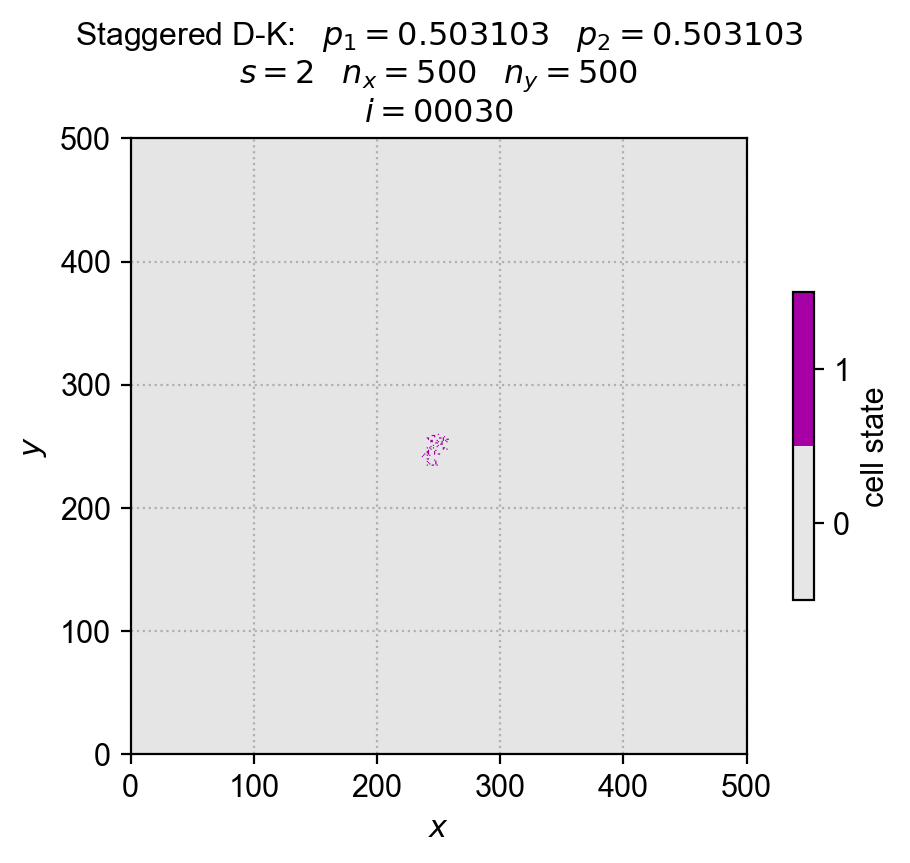

lattice_p0p503103_s2_nx500_ny500_i00060


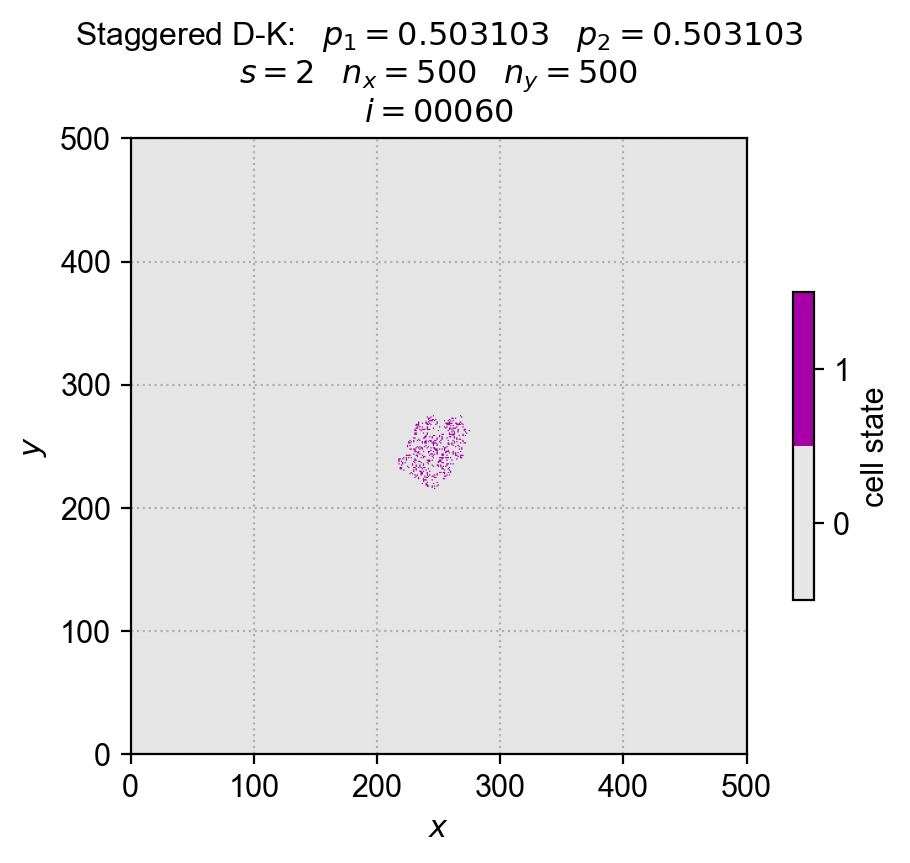

lattice_p0p503103_s2_nx500_ny500_i00090


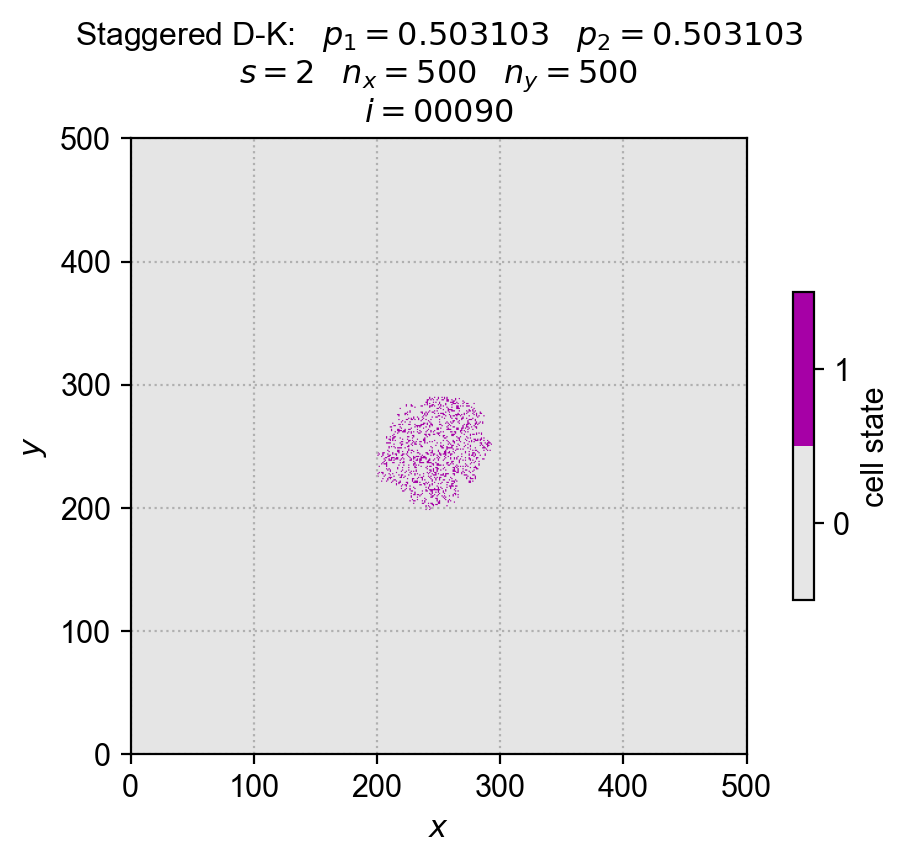

In [9]:
if n_lattices>0:
    i_slice = 30
    name = make_name(parameters, "lattice", i_slice,)
    print(name)
    image_lattice(
        name=name, title=make_title(parameters, i_slice), i_lattice=i_slice,
    )
    plt.show()
    i_slice = 60
    name = make_name(parameters, "lattice", i_slice,)
    print(name)
    image_lattice(
        name=name, title=make_title(parameters, i_slice), i_lattice=i_slice,
    )
    plt.show()
    i_slice = 90
    name = make_name(parameters, "lattice", i_slice,)
    print(name)
    image_lattice(
        name=name, title=make_title(parameters, i_slice), i_lattice=i_slice,
    )
    plt.show()

Visualize the final lattice:

lattice_p0p503103_s2_nx500_ny500_i00250


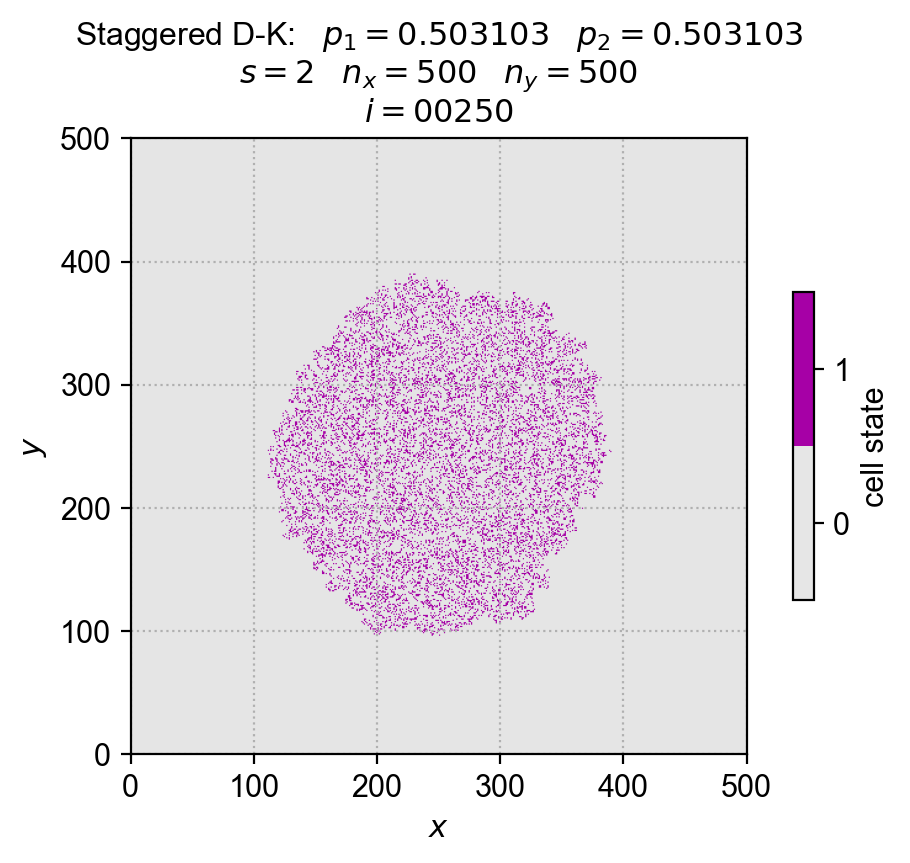

In [10]:
if n_lattices>=1:
    i_slice = (n_lattices-1)
    name = make_name(parameters, "lattice", i_slice,)
    print(name)
    image_lattice(
        name=name, title=make_title(parameters, i_slice), i_lattice=i_slice,
    )
    plt.show()

### History

See Henkel et al (2008), tables 4.1 and 4.3: the decay rate of the mean order parameter (mean occupancy) $\overline\rho$ should decay with time as
$$
    \rho(t) \sim t^{-\delta}
$$
where in $d=2$ we should find $\delta \approx 0.4505$. 

ρmean_p0p503103_s2_nx500_ny500


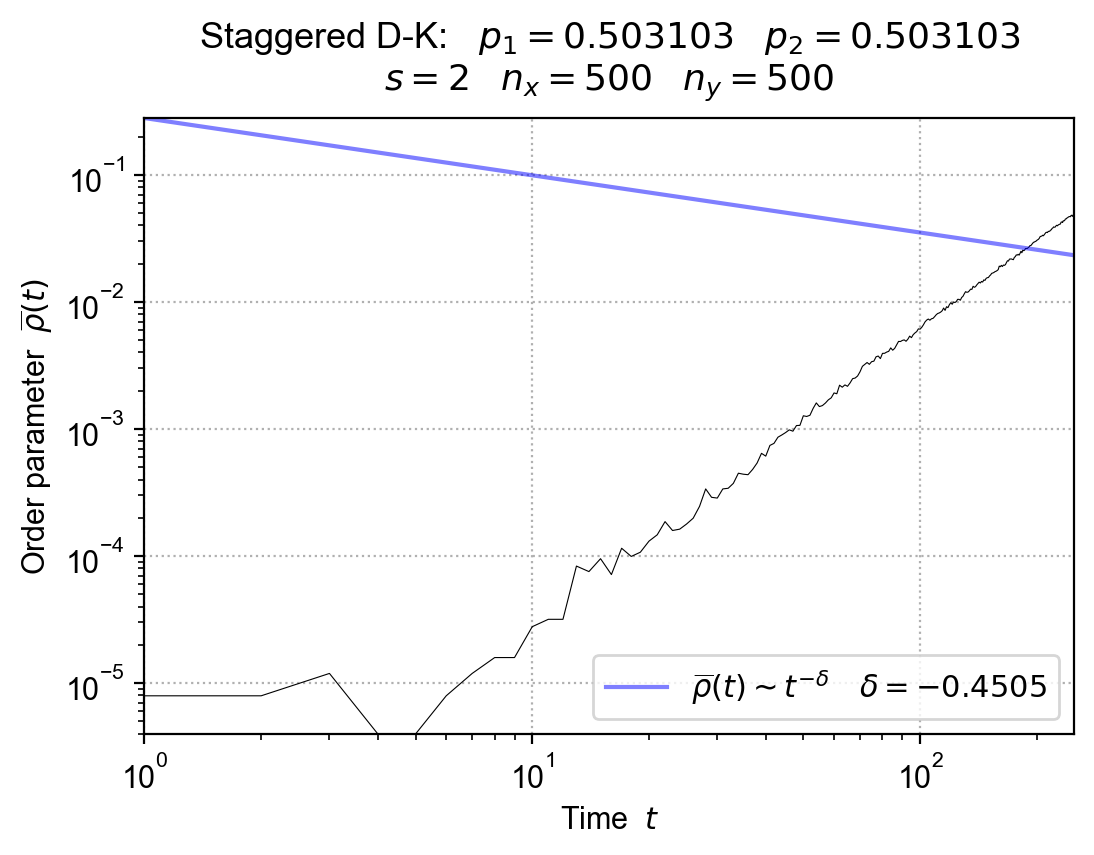

In [11]:
δ = 0.45051
# scale = 0.38
scale = 0.28

name = make_name(parameters, "ρmean", None, )
print(name)
viz.plot_lattice_statistic(
    name,
    make_title(parameters, None),
    tracking,
    choices=("time", "ρ_mean"),
    labels=(
        "Order parameter  $\\widebar{\\rho}(t)$", 
        "$\\widebar{\\rho}(t) \\sim t^{-\\delta}$",
        "${\\delta}$",
    ),
    exponent=-δ, 
    scale=scale,
    i_offset=1,
    do_ref_curve=True,
)
plt.show()

In [12]:
i_offset: int = parameters.n_iterations//50
t: NDArray = tracking["time"][i_offset:]
ρ_mean: NDArray = tracking["ρ_mean"][i_offset:]
(exponent, scale, r_value, p_value, std_err) \
    = linregress(np.log(t), np.log(ρ_mean))
print(tracking["time"][i_offset])
print(rf"Estimated t-decay exponent:  δ = {exponent:0.3f}")

10.0
Estimated t-decay exponent:  δ = 2.355


0.5662462854243676
Rmean_p0p503103_s2_nx500_ny500


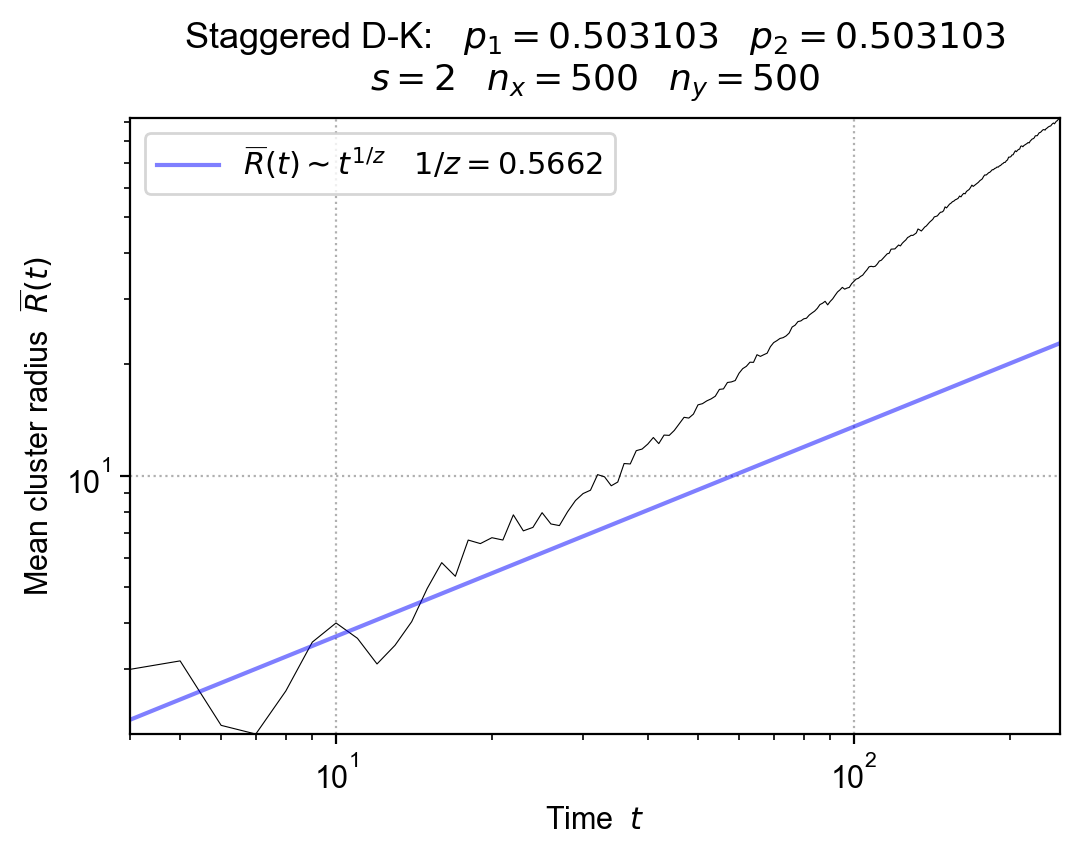

In [13]:
if parameters.initial_condition==InitialCondition.CentralSeed:
    z = 1.766016
    # z = 1
    print(1/z)
    scale = 1

    name = make_name(parameters, "Rmean", None, )
    print(name)
    viz.plot_lattice_statistic(
        name,
        make_title(parameters, None),
        tracking,
        choices=("time", "R_mean"),
        labels=(
            "Mean cluster radius  $\\widebar{R}(t)$", 
            "$\\widebar{R}(t) \\sim t^{1/z}$",
            "$1/z$",
        ),
        exponent=1/z, 
        scale=scale,
        i_offset=4,
        do_ref_curve=True,
    )
    plt.show()

<hr>

## Export

In [14]:
plots_dir: str = create_directories((os.path.curdir,"plots",), "dp2d")
export_plots(
    viz.fdict,
    plots_dir,
    "PNG",
    suffix="",
    dpi=150,
)

'././plots/dp2d'